# Segmentation (KMeans) et géo-localisation (Folium) des clients
Le but de ce kata est de vous familiariser avec l'utilisation de KMeans pour segmenter des clients, et avec l'utilisation de Folium pour présenter des données géographiques.

In [1]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/ylebecque/SQL_DBs/refs/heads/main/customer_location_data.csv")

df.head()

,Customer ID,Name,Address,Phone Number,Order Frequency,Latitude,Longitude,Total Spend
0,1,Morgan Miller,"3871 Pine St, Chicago, CA 61204",740-188-1791,10,41.594931,-86.538644,256.58
1,2,Alex Jones,"2256 Main St, New York, AZ 85824",(821) 242-1461,45,41.208164,-81.406966,1199.32
2,3,Jordan Williams,"7208 Pine St, Houston, IL 10633",(935) 533-3098,48,37.112489,-108.529631,2940.36
3,4,Alex Jones,"9654 Main St, Chicago, AZ 29989",908.146.3028,3,39.408358,-115.697062,4940.79
4,5,Casey Johnson,"1489 Oak St, Houston, IL 47427",(808) 949-6016,24,40.186664,-85.615365,923.36


# Clustering

Dans un premier temps, analysez les données et déterminez un modèle de clustering pour séparer les clients. Sous chaque cellule de code, vous trouverez une cellule cachée qui contient du "code à trous" si vous ne vous sentez pas prêt à tout coder tout seul.

In [2]:
# Affichez le nombre de lignes et de colonnes du dataframe
df.shape

(100, 8)

### Vérifiez l'unicité des clients dans le dataframe

In [3]:
# Vérifiez l'unicité des clients dans le dataframe

print(f"Il y a {df['Name'].nunique()} clients dans le dataframe")

Il y a 64 clients dans le dataframe


In [4]:
# Je vérifie si il y a des NaN
df.isna().sum()

Customer ID        0
Name               0
Address            0
Phone Number       0
Order Frequency    0
Latitude           0
Longitude          0
Total Spend        0
dtype: int64

In [5]:
# Je verifie si il y a des doublons
df.duplicated().sum()

0

### Utilisez SKlearn et Yellowbrick pour entraîner un modèle KMeans et trouver les meilleurs paramètres

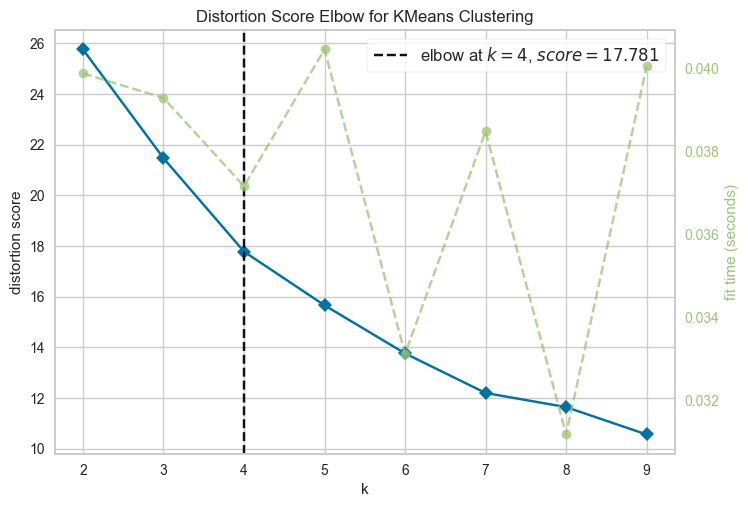

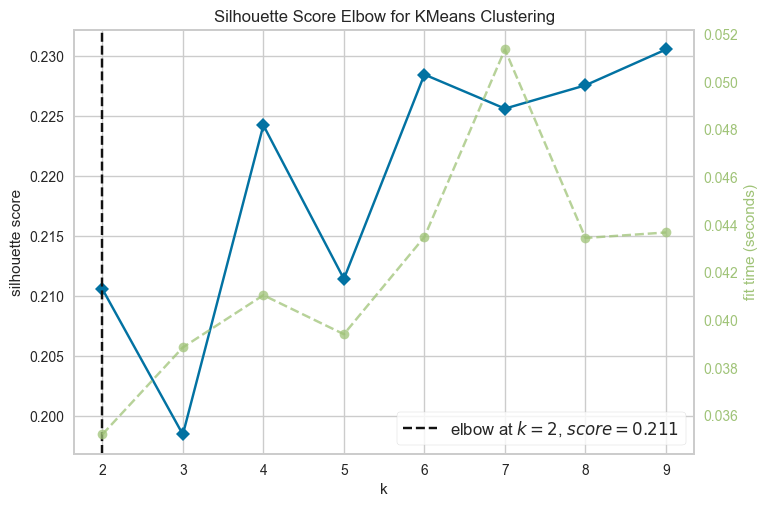

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Sélection et standardisation des données
X = df[["Order Frequency", "Latitude", "Longitude", "Total Spend"]] # Je selectionne mes features

# Je choisis minmaxscaler parce que KMeans est basé sur des distances et MinMaxScaler met toutes les features sur la même échelle (0 à 1), 
# évitant que Total Spend domine le calcul à cause de ses grandes valeurs.
X_scaled = MinMaxScaler().fit_transform(X)

# modèle
model = KMeans(n_init=10)

# Recherche du meilleur paramètre k avec Elbow / Silhouette
visualiser = KElbowVisualizer(model, k=(2, 10))

visualiser.fit(X_scaled)

visualiser.show()

visualiser = KElbowVisualizer(model, k=(2, 10), metric = 'silhouette')

visualiser.fit(X_scaled)

visualiser.show()

plt.show()

Je choisis 4 clusters car la methode Elbow m'indique 4 et le silouhette score a un score intéressant sur 4 même si il conseille 2 clusters, le plus pertinent semble etre 4 clusters.

### Créez un modèle KMeans avec les paramètres précédents

In [17]:
# Création du modèle avec le nombre de clusters optimal
model = KMeans(n_clusters=4, n_init=10)

# Entrainement du modèle sur les données standardisées
segment = model.fit_predict(X_scaled)

# Ajout des clusters dans une nouvelle colonne 'Segment'
df['Segment'] = model.labels_

df.head()

,Customer ID,Name,Address,Phone Number,Order Frequency,Latitude,Longitude,Total Spend,Segment
0,1,Morgan Miller,"3871 Pine St, Chicago, CA 61204",740-188-1791,10,41.594931,-86.538644,256.58,1
1,2,Alex Jones,"2256 Main St, New York, AZ 85824",(821) 242-1461,45,41.208164,-81.406966,1199.32,3
2,3,Jordan Williams,"7208 Pine St, Houston, IL 10633",(935) 533-3098,48,37.112489,-108.529631,2940.36,3
3,4,Alex Jones,"9654 Main St, Chicago, AZ 29989",908.146.3028,3,39.408358,-115.697062,4940.79,2
4,5,Casey Johnson,"1489 Oak St, Houston, IL 47427",(808) 949-6016,24,40.186664,-85.615365,923.36,1


#### Indice

# Visualisation

Ici, nous allons tracer des boxplots affichant la fréquence, puis le total dépensé en fonction des semgents de clients

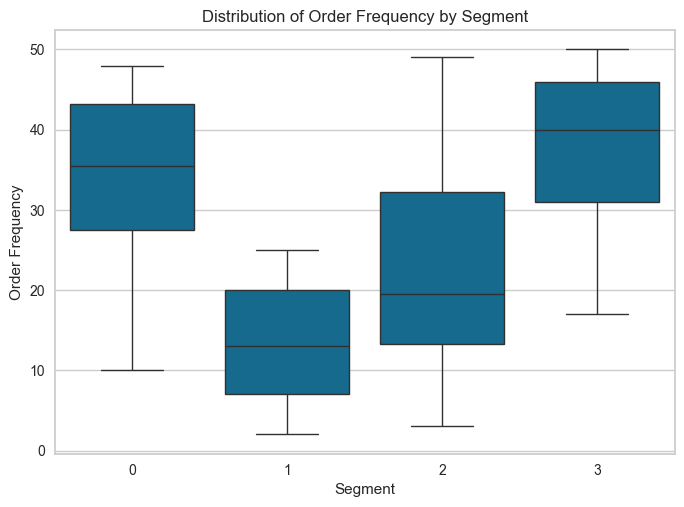

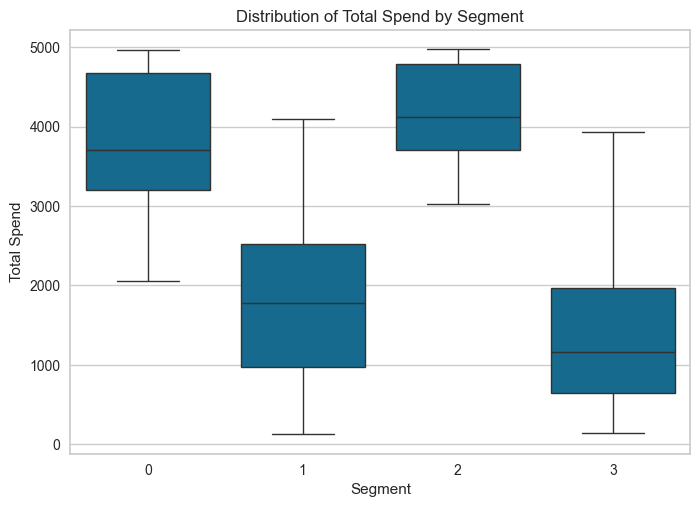

In [18]:
# Affichage des boxplots des différents segments de clients
import seaborn as sns

# Sélection des colonnes
cols = ["Order Frequency", "Total Spend"]

# Affichage des boxplots
for col in cols:
    sns.boxplot(x='Segment', y=col, data=df)
    plt.title(f'Distribution of {col} by Segment')
    plt.show()


# Cartographie

Enfin, nous allons afficher une carte des clients. Cette carte devra afficher l'ensemble des clients et indiquer visuellement à quel cluster ils appartiennent. Vous pouvez aussi afficher leur nom et leur adresse dans une pop-up.

Pour choisir la couleur d'un Marker, il faut lui passer le paramètre color=

In [20]:
import folium

mlat = df.Latitude.mean()
mlon = df.Longitude.mean()
colors = {0: 'red', 1 : 'orange', 2 : 'green', 3 : 'blue'}

# Ajout des Markers
Folium_markers = [folium.Marker(location=[row['Latitude'], row['Longitude']], 
                            popup=row['Name'], 
                            icon=folium.Icon(color=colors[row['Segment']])) for index, row in df.iterrows()]
# Affichage de la carte
m = folium.Map(location=[mlat, mlon], zoom_start=5)

m